# Pit Shell and Blast Master Generator

This notebook is a working build-up of a pit shell and blast master layout.

Starting with a simple pit footprint, then stepping through:
- defining the toe line from bench geometry;
- carving out the trim buffer;
- placing the ramp and slot;
- generating the first production blast;
- then manually laying out the remaining production blasts.

The idea is to keep this as a clean, controlled baseline before automating more of the logic later. Most of this is about getting the geometry behaving properly and making sure the patterns look and feel realistic.

Later on I’ll expand this into sequencing, full blast master generation, and exporting something usable downstream.

## 1. Imports

Pulling in the core libraries for geometry, data handling and plotting.

Shapely does most of the heavy lifting for the geometry. Matplotlib is just for quick visual checks.

In [1]:
import os
import math
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from shapely.geometry import Point, Polygon, MultiPolygon, GeometryCollection, LineString, box
from shapely.ops import unary_union
from shapely.ops import substring
from shapely.affinity import rotate, scale, translate
import ipywidgets as widgets
import plotly.graph_objects as go
from IPython.display import display, clear_output

## 2. Inputs

All the main user inputs live here - pit size, bench geometry, trim width, ramp settings, slot size, etc.

If something looks off later, this is the first place to come back to.

In [2]:
# --- Block model file ---
block_model_file = "block_model_v2.csv"

# --- Manual context geometry file ---
# manual_context_geometry_file = "manual_blast_geometry_20260502_112546.csv"

# Use "absolute" for x/y mine-grid coordinates, or "local" for x_m/y_m.
coord_mode = "absolute"

def _resolve_input_file(path: str, fallbacks: list[str] | None = None) -> str:
    """Resolve a file path for notebook/local and /mnt/data execution."""
    fallbacks = fallbacks or []

    candidates = [
        path,
        os.path.join(os.getcwd(), path),
        os.path.join("/mnt/data", os.path.basename(path)),
    ] + fallbacks

    for candidate in candidates:
        if candidate and os.path.exists(candidate):
            return candidate

    raise FileNotFoundError(
        f"Could not find {path!r}. Tried: " + ", ".join(candidates)
    )


block_model_file = _resolve_input_file(block_model_file)
block_model_df = pd.read_csv(block_model_file)

if coord_mode.lower() == "absolute":
    x_col, y_col = "x", "y"
elif coord_mode.lower() == "local":
    x_col, y_col = "x_m", "y_m"
else:
    raise ValueError("coord_mode must be either 'absolute' or 'local'.")

# ============================================================
# ECONOMIC / PIT-SHELL PROXY SETTINGS
# ============================================================
# This is a starter shell, not a Lerchs-Grossmann optimisation. It builds a
# practical mining shell around Au-Cu-Ag mineralisation using an AuEq proxy.

assumed_gold_price_usd_oz = 2200.0
assumed_copper_price_usd_lb = 4.00
assumed_silver_price_usd_oz = 25.0

pit_shell_cutoff_au_eq_gpt = 0.55
pit_shell_include_domains = [
    "high_grade_core",
    "stockwork_ore",
]
pit_shell_exclude_lithologies = [
    "late_mafic_dyke",
    "barren_diorite_intrusion",
]

# Operational shell expansion and smoothing around the mineralised driver.
shell_dilation_m = 50.0
shell_smoothing_m = 42.0
shell_simplify_tolerance_m = 4.0
shell_boundary_smooth_iterations = 2
minimum_shell_component_area_m2 = 10_000.0

# ============================================================
# BENCH / WALL DESIGN
# ============================================================
# Read RLs from the single-RL block model slice.

crest_rl = float(block_model_df["z_top_m"].max())
floor_rl = float(block_model_df["z_bottom_m"].min())
bench_height_m = crest_rl - floor_rl

wall_angle_deg = 70.0

# ============================================================
# CAT 793 / KOMATSU PC8000 STARTER ASSUMPTIONS
# ============================================================
# Cat 793-class truck width is approximately 8 m depending on tray/options.
# A two-way production ramp is set to about 3.5 truck widths plus allowance for
# windrow/berm, drain, and operating clearance.

haul_truck_model = "Caterpillar 793-class"
haul_truck_width_m = 8.0
haul_road_traffic = "two-way"          # "one-way" or "two-way"
haul_road_width_factor = 3.5 if haul_road_traffic == "two-way" else 2.0
haul_road_extra_allowance_m = 7.0
minimum_ramp_width_m = 35.0

ramp_width_m = max(
    minimum_ramp_width_m,
    haul_truck_width_m * haul_road_width_factor + haul_road_extra_allowance_m,
)

# Use the ramp width as the toe-based trim / road corridor width.
trim_buffer_width_m = ramp_width_m

# 1:10 is a reasonable starter gradient for large truck open-pit access.
ramp_gradient_ratio = 10.0
preferred_ramp_side = "south"          # "auto", "south", "north", "east", "west"
candidate_ramp_sides = ["south", "west", "north", "east"]

excavator_model = "Komatsu PC8000 face shovel"
excavator_bucket_m3 = 42.0

# Ramp and slot are fixed access designs; production/trim blasts are drawn manually.
slot_length_m = 110.0
slot_width_m = trim_buffer_width_m
slot_development_direction = "clockwise"

# Straight access-search settings. The algorithm scans the requested wall side
# for a long, straight-ish trim-corridor section that can fit the ramp and slot
# at full corridor width.
access_search_spacing_m = 5.0
access_side_fraction = 0.28
access_outer_edge_inset_m = 0.0
access_minimum_full_width_fit = 0.965

# Manual blast drawing defaults. Pattern 1 = ramp, Pattern 2 = slot, so
# manually drawn production/trim blasts start at Pattern 3.
manual_blast_counter_start = 3
production_blast_length_m = 110.0      # reference only, m
production_blast_depth_m = 90.0        # reference only, m

# Manual legacy-design handling in the load widget.
default_legacy_geometry_transform = "none"  # "none" or "fit_bounds_to_current_shell"

# ============================================================
# DERIVED VALUES
# ============================================================

wall_angle_rad = math.radians(wall_angle_deg)
toe_offset_m = bench_height_m / math.tan(wall_angle_rad)
ramp_length_m = bench_height_m * ramp_gradient_ratio

print(f"Loaded block model: {block_model_file}")
print(f"Coordinate mode: {coord_mode} ({x_col}, {y_col})")
print(f"Block count: {len(block_model_df):,}")
print(f"Crest RL: {crest_rl:.2f} m")
print(f"Floor RL: {floor_rl:.2f} m")
print(f"Bench height: {bench_height_m:.2f} m")
print(f"Bench-face angle: {wall_angle_deg:.1f} degrees")
print(f"Toe-line inward offset: {toe_offset_m:.2f} m")
print(f"Haul truck: {haul_truck_model}")
print(f"Excavator: {excavator_model}, nominal bucket {excavator_bucket_m3:.0f} m³")
print(f"Ramp gradient: 1:{ramp_gradient_ratio:.1f}")
print(f"Ramp / trim corridor width: {ramp_width_m:.1f} m")
print(f"Required one-bench ramp length: {ramp_length_m:.1f} m")
print(f"Slot length / width: {slot_length_m:.1f} m / {slot_width_m:.1f} m")
print(f"Manual blast IDs start at Pattern {manual_blast_counter_start}.")
print(f"Reference production blast length/depth: {production_blast_length_m:.1f} m / {production_blast_depth_m:.1f} m")

Loaded block model: block_model_v2.csv
Coordinate mode: absolute (x, y)
Block count: 5,892
Crest RL: 200.00 m
Floor RL: 185.00 m
Bench height: 15.00 m
Bench-face angle: 70.0 degrees
Toe-line inward offset: 5.46 m
Haul truck: Caterpillar 793-class
Excavator: Komatsu PC8000 face shovel, nominal bucket 42 m³
Ramp gradient: 1:10.0
Ramp / trim corridor width: 35.0 m
Required one-bench ramp length: 150.0 m
Slot length / width: 110.0 m / 35.0 m
Manual blast IDs start at Pattern 3.
Reference production blast length/depth: 110.0 m / 90.0 m


## 3. Helper functions

A mix of geometry utilities and small helpers used throughout.

Nothing fancy here - just keeping the main cells cleaner so the workflow is easier to follow.

In [3]:
def smooth_cyclic(values: np.ndarray, window: int) -> np.ndarray:
    """Smooth a cyclic 1D array using a centred moving average."""
    window = int(max(1, window))

    if window % 2 == 0:
        window += 1

    if window <= 1:
        return values

    pad = window // 2
    padded = np.r_[values[-pad:], values, values[:pad]]
    kernel = np.ones(window) / window

    return np.convolve(padded, kernel, mode="valid")


def chaikin_smooth_ring(coords: np.ndarray, iterations: int = 2) -> np.ndarray:
    """Smooth a closed ring using Chaikin corner cutting."""
    pts = np.asarray(coords, dtype=float)

    if len(pts) < 4:
        return pts

    if not np.allclose(pts[0], pts[-1]):
        pts = np.vstack([pts, pts[0]])

    for _ in range(int(max(0, iterations))):
        new_pts = []
        n = len(pts) - 1

        for i in range(n):
            p0 = pts[i]
            p1 = pts[(i + 1) % n]
            q = 0.75 * p0 + 0.25 * p1
            r = 0.25 * p0 + 0.75 * p1
            new_pts.extend([q, r])

        pts = np.vstack([np.asarray(new_pts), np.asarray(new_pts)[0]])

    return pts


def smooth_polygon_boundary(poly: Polygon, iterations: int = 2) -> Polygon:
    """Round sharp corners on a polygon while keeping a single outer shell."""
    poly = clean_polygon(poly)

    if poly.is_empty:
        return Polygon()

    exterior = np.array(poly.exterior.coords)
    smoothed = chaikin_smooth_ring(exterior, iterations=iterations)
    return clean_polygon(Polygon(smoothed))


def create_irregular_pit_shell(
    strike_length: float,
    pit_width: float,
    centre: tuple[float, float],
    n_points: int,
    irregularity: float,
    smoothing_window: int,
    seed: int,
) -> np.ndarray:
    """Fallback: create an irregular east-west elongated pit shell polygon."""
    rng = np.random.default_rng(seed)
    theta = np.linspace(0, 2 * np.pi, n_points, endpoint=False)

    noise = rng.normal(0, 1, n_points)
    smooth_noise = smooth_cyclic(noise, smoothing_window)
    smooth_noise = smooth_noise / max(np.max(np.abs(smooth_noise)), 1e-9)

    radial_multiplier = 1.0 + irregularity * smooth_noise

    a = strike_length / 2.0
    b = pit_width / 2.0
    cx, cy = centre

    x = cx + a * np.cos(theta) * radial_multiplier
    y = cy + b * np.sin(theta) * radial_multiplier

    return np.column_stack([x, y])


def iter_polygon_parts(geom, min_area: float = 0.0):
    """Yield polygonal parts from Polygon, MultiPolygon, or GeometryCollection."""
    if geom is None or geom.is_empty:
        return

    if geom.geom_type == "Polygon":
        if geom.area >= min_area:
            yield geom

    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            if poly.area >= min_area:
                yield poly

    elif geom.geom_type == "GeometryCollection":
        for part in geom.geoms:
            yield from iter_polygon_parts(part, min_area=min_area)


def clean_geometry(geom):
    """Repair invalid geometry while preserving polygonal components."""
    if geom is None or geom.is_empty:
        return geom

    if not geom.is_valid:
        geom = geom.buffer(0)

    if geom.geom_type == "GeometryCollection":
        parts = list(iter_polygon_parts(geom))
        if not parts:
            return Polygon()
        geom = unary_union(parts)

    if not geom.is_valid:
        geom = geom.buffer(0)

    return geom


def clean_polygon(poly: Polygon) -> Polygon:
    """Repair minor invalid polygon geometry and keep the largest part."""
    poly = clean_geometry(poly)

    if poly is None or poly.is_empty:
        return Polygon()

    parts = list(iter_polygon_parts(poly))

    if not parts:
        return Polygon()

    return max(parts, key=lambda g: g.area)


def safe_difference(a, b):
    """Difference with geometry clean-up."""
    return clean_geometry(clean_geometry(a).difference(clean_geometry(b)))


def safe_intersection(a, b):
    """Intersection with geometry clean-up."""
    return clean_geometry(clean_geometry(a).intersection(clean_geometry(b)))


def safe_union(geoms):
    """Union with geometry clean-up."""
    geoms = [g for g in geoms if g is not None and not g.is_empty]

    if not geoms:
        return Polygon()

    return clean_geometry(unary_union(geoms))


def infer_block_size(df: pd.DataFrame, x_col: str, y_col: str) -> tuple[float, float]:
    """Infer x/y block spacing from centre coordinates."""
    x_unique = np.sort(df[x_col].dropna().unique())
    y_unique = np.sort(df[y_col].dropna().unique())

    dx_values = np.diff(x_unique)
    dy_values = np.diff(y_unique)

    dx = float(np.median(dx_values[dx_values > 0])) if np.any(dx_values > 0) else 10.0
    dy = float(np.median(dy_values[dy_values > 0])) if np.any(dy_values > 0) else dx

    return dx, dy


def add_value_proxy_columns(
    df: pd.DataFrame,
    gold_price_usd_oz: float,
    copper_price_usd_lb: float,
    silver_price_usd_oz: float,
) -> pd.DataFrame:
    """Add recovered AuEq and a simple value score to the block model dataframe."""
    out = df.copy()

    # 1% Cu = 22.046 lb Cu per tonne of rock. Convert value to equivalent g/t Au.
    cu_pct_to_au_eq_gpt = 22.0462262 * copper_price_usd_lb / (
        gold_price_usd_oz / 31.1034768
    )
    ag_gpt_to_au_eq_gpt = silver_price_usd_oz / gold_price_usd_oz

    for col, default in [
        ("rec_au", 1.0),
        ("rec_cu", 1.0),
        ("rec_ag", 1.0),
        ("au_gpt", 0.0),
        ("cu_pct", 0.0),
        ("ag_gpt", 0.0),
    ]:
        if col not in out.columns:
            out[col] = default

    out["au_eq_gpt"] = (
        out["au_gpt"] * out["rec_au"]
        + out["cu_pct"] * out["rec_cu"] * cu_pct_to_au_eq_gpt
        + out["ag_gpt"] * out["rec_ag"] * ag_gpt_to_au_eq_gpt
    )

    out["value_proxy"] = out["au_eq_gpt"]

    return out


def block_rectangles_from_mask(
    df: pd.DataFrame,
    mask: pd.Series | np.ndarray,
    x_col: str,
    y_col: str,
    block_dx: float,
    block_dy: float,
):
    """Return Shapely rectangles for selected block centres."""
    selected = df.loc[mask, [x_col, y_col]]

    return [
        box(
            row[x_col] - block_dx / 2.0,
            row[y_col] - block_dy / 2.0,
            row[x_col] + block_dx / 2.0,
            row[y_col] + block_dy / 2.0,
        )
        for _, row in selected.iterrows()
    ]


def create_shell_from_block_model(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    cutoff_au_eq_gpt: float,
    include_domains: list[str],
    exclude_lithologies: list[str],
    dilation_m: float,
    smoothing_m: float,
    simplify_tolerance_m: float,
    minimum_component_area_m2: float,
) -> tuple[Polygon, pd.Series, tuple[float, float]]:
    """Create a practical pit-shell footprint from mineralised block-model drivers."""
    block_dx, block_dy = infer_block_size(df, x_col, y_col)

    domain_mask = pd.Series(False, index=df.index)

    if "mineral_domain" in df.columns and include_domains:
        domain_mask = df["mineral_domain"].isin(include_domains)

    grade_mask = df["au_eq_gpt"] >= cutoff_au_eq_gpt

    driver_mask = grade_mask | domain_mask

    if "lithology" in df.columns and exclude_lithologies:
        driver_mask = driver_mask & ~df["lithology"].isin(exclude_lithologies)

    if driver_mask.sum() == 0 and "location" in df.columns:
        driver_mask = df["location"].astype(str).str.lower().eq("ore")

    if driver_mask.sum() == 0:
        raise ValueError("No pit-shell driver blocks found. Lower the cutoff or check domain names.")

    driver_rectangles = block_rectangles_from_mask(
        df=df,
        mask=driver_mask,
        x_col=x_col,
        y_col=y_col,
        block_dx=block_dx,
        block_dy=block_dy,
    )

    driver_union = safe_union(driver_rectangles)

    # Operational shell around the driver. The positive buffer allows waste
    # pushback and working room. Round-join buffering plus a light boundary
    # smoothing step produces a more practical, less angular mining crest.
    shell = driver_union.buffer(dilation_m, join_style=1)

    if smoothing_m > 0:
        shell = shell.buffer(smoothing_m, join_style=1).buffer(-smoothing_m, join_style=1)

    shell = clean_geometry(shell)

    components = list(iter_polygon_parts(shell, min_area=minimum_component_area_m2))

    if not components:
        components = list(iter_polygon_parts(shell))

    if not components:
        raise ValueError("Pit shell collapsed during smoothing/simplification.")

    pit_shell = max(components, key=lambda g: g.area)
    pit_shell = clean_polygon(pit_shell)

    if simplify_tolerance_m > 0:
        pit_shell = clean_polygon(
            pit_shell.buffer(simplify_tolerance_m, join_style=1).buffer(-simplify_tolerance_m, join_style=1)
        )
        pit_shell = clean_polygon(
            pit_shell.simplify(max(0.5, simplify_tolerance_m / 2.0), preserve_topology=True)
        )

    try:
        pit_shell = smooth_polygon_boundary(
            pit_shell,
            iterations=globals().get("shell_boundary_smooth_iterations", 2),
        )
    except Exception:
        pit_shell = clean_polygon(pit_shell)

    return pit_shell, driver_mask, (block_dx, block_dy)


def inward_offset_polygon(coords: np.ndarray, offset_distance: float) -> np.ndarray:
    """Offset a polygon inward using Shapely negative buffer."""
    if offset_distance <= 0:
        return coords.copy()

    poly = clean_polygon(Polygon(coords))
    inner = clean_polygon(poly.buffer(-offset_distance, join_style=2))

    if inner.is_empty:
        raise ValueError("Inward offset collapsed the polygon.")

    return np.array(inner.exterior.coords[:-1])


def polygon_area(coords: np.ndarray) -> float:
    """Calculate polygon area using the shoelace formula."""
    x = coords[:, 0]
    y = coords[:, 1]

    return 0.5 * abs(
        np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))
    )


def coords_to_dataframe(coords: np.ndarray, line_name: str, rl: float) -> pd.DataFrame:
    """Convert polygon coordinates to a tidy dataframe."""
    df = pd.DataFrame(coords, columns=["x", "y"])
    df.insert(0, "point_id", np.arange(1, len(df) + 1))
    df.insert(1, "line_name", line_name)
    df["rl"] = rl

    return df


def circular_substring(line: LineString, start_dist: float, length: float) -> LineString:
    """Extract a section from a closed LineString, allowing wrap-around."""
    total_length = line.length

    if total_length <= 0:
        raise ValueError("Line has zero length.")

    start_dist = start_dist % total_length
    end_dist = start_dist + length

    if end_dist <= total_length:
        return substring(line, start_dist, end_dist)

    first_part = substring(line, start_dist, total_length)
    second_part = substring(line, 0, end_dist - total_length)

    coords = list(first_part.coords) + list(second_part.coords)
    return LineString(coords)


def compactness_ratio(geom) -> float:
    """Simple shape-quality check based on minimum rotated rectangle."""
    if geom.is_empty or geom.area <= 0:
        return 0.0

    min_rect = geom.minimum_rotated_rectangle

    if min_rect.area <= 0:
        return 0.0

    return geom.area / min_rect.area


def plot_polygon(
    ax,
    geom,
    facecolor="none",
    edgecolor="black",
    alpha=1.0,
    linewidth=2,
    label=None,
    zorder=None,
):
    """Plot a Shapely Polygon, MultiPolygon, or GeometryCollection."""
    if geom is None or geom.is_empty:
        return

    label_used = False

    for poly in iter_polygon_parts(geom):
        x, y = poly.exterior.xy

        ax.fill(
            x,
            y,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
            linewidth=linewidth,
            label=label if not label_used else None,
            zorder=zorder,
        )

        label_used = True

        for interior in poly.interiors:
            ix, iy = interior.xy
            ax.fill(ix, iy, facecolor="white", edgecolor=edgecolor, linewidth=1)


def setup_plan_axis(ax, title: str):
    """Apply common formatting to plan-view plots."""
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Easting / X (m)")
    ax.set_ylabel("Northing / Y (m)")
    ax.grid(True, alpha=0.25)

    ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="upper right")


def get_reference_boundary_point(boundary: LineString, side: str) -> tuple[float, float]:
    """Return the boundary point used to place the ramp."""
    coords = list(boundary.coords)

    if side.lower() == "south":
        idx = min(range(len(coords)), key=lambda i: coords[i][1])
    elif side.lower() == "north":
        idx = max(range(len(coords)), key=lambda i: coords[i][1])
    elif side.lower() == "east":
        idx = max(range(len(coords)), key=lambda i: coords[i][0])
    elif side.lower() == "west":
        idx = min(range(len(coords)), key=lambda i: coords[i][0])
    else:
        raise ValueError("side must be one of: south, north, east, west.")

    return coords[idx]


def make_boundary_rectangle(
    segment: LineString,
    reference_polygon: Polygon,
    offset_inward_m: float,
    depth_m: float,
) -> Polygon:
    """
    Create a straight-sided rectangular polygon from a boundary segment.

    The rectangle uses the segment start and end points as its width direction.
    It is then projected inward from the reference polygon boundary.
    """
    coords = list(segment.coords)

    if len(coords) < 2:
        raise ValueError("Segment must contain at least two coordinates.")

    p0 = np.array(coords[0], dtype=float)
    p1 = np.array(coords[-1], dtype=float)

    tangent = p1 - p0
    tangent_length = np.linalg.norm(tangent)

    if tangent_length <= 1e-9:
        raise ValueError("Segment has negligible length.")

    tangent = tangent / tangent_length

    n1 = np.array([-tangent[1], tangent[0]])
    n2 = np.array([tangent[1], -tangent[0]])

    midpoint = (p0 + p1) / 2.0
    centroid = np.array([reference_polygon.centroid.x, reference_polygon.centroid.y])

    inward = n1 if np.dot(centroid - midpoint, n1) > np.dot(centroid - midpoint, n2) else n2

    outer_left = p0 + inward * offset_inward_m
    outer_right = p1 + inward * offset_inward_m
    inner_right = p1 + inward * (offset_inward_m + depth_m)
    inner_left = p0 + inward * (offset_inward_m + depth_m)

    return clean_polygon(Polygon([outer_left, outer_right, inner_right, inner_left]))


def geometry_area_ratio(candidate: Polygon, clipped) -> float:
    """Return clipped area as a proportion of original candidate area."""
    if candidate.is_empty or candidate.area <= 0:
        return 0.0

    if clipped.is_empty:
        return 0.0

    return clipped.area / candidate.area


def make_ramp_candidate(
    design_boundary: LineString,
    trim_zone,
    ramp_side: str,
    ramp_length: float,
    ramp_width: float,
) -> tuple[object, LineString, float, float]:
    """Build a ramp polygon candidate for a nominated boundary side."""
    ramp_point = get_reference_boundary_point(design_boundary, ramp_side)
    ramp_centre_distance = design_boundary.project(Point(ramp_point))

    ramp_start_distance = ramp_centre_distance - ramp_length / 2.0
    ramp_end_distance = ramp_centre_distance + ramp_length / 2.0

    ramp_outer_segment = circular_substring(
        design_boundary,
        ramp_start_distance,
        ramp_length,
    )

    ramp_corridor = ramp_outer_segment.buffer(
        ramp_width * 1.5,
        cap_style=2,
        join_style=2,
    )

    final_ramp_polygon = safe_intersection(trim_zone, ramp_corridor)

    return (
        final_ramp_polygon,
        ramp_outer_segment,
        ramp_start_distance % design_boundary.length,
        ramp_end_distance % design_boundary.length,
    )


def point_mask_in_polygon(
    df: pd.DataFrame,
    geom,
    x_col: str,
    y_col: str,
) -> np.ndarray:
    """Return boolean mask for block centres inside/touching a geometry."""
    if geom is None or geom.is_empty:
        return np.zeros(len(df), dtype=bool)

    return np.array([
        geom.contains(Point(x, y)) or geom.touches(Point(x, y))
        for x, y in zip(df[x_col], df[y_col])
    ])


def evaluate_ramp_sides(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    design_boundary: LineString,
    trim_zone,
    sides: list[str],
    ramp_length: float,
    ramp_width: float,
) -> pd.DataFrame:
    """Rank candidate ramp sides using grade loss and geotechnical exposure."""
    rows = []

    for side in sides:
        ramp_poly, _, _, _ = make_ramp_candidate(
            design_boundary=design_boundary,
            trim_zone=trim_zone,
            ramp_side=side,
            ramp_length=ramp_length,
            ramp_width=ramp_width,
        )

        mask = point_mask_in_polygon(df, ramp_poly, x_col, y_col)
        sample = df.loc[mask].copy()

        mean_au_eq = float(sample["au_eq_gpt"].mean()) if len(sample) else np.nan
        ore_fraction = float((sample.get("location", "").astype(str).str.lower() == "ore").mean()) if len(sample) and "location" in sample.columns else 0.0
        mean_rmr = float(sample["RMR"].mean()) if len(sample) and "RMR" in sample.columns else np.nan
        mean_fault_dist = float(sample["fault_dist_m"].mean()) if len(sample) and "fault_dist_m" in sample.columns else np.nan

        # Lower is better: avoid metal, avoid ore, avoid low-RMR/faulted ground.
        score = 0.0
        score += 5.0 * (0.0 if np.isnan(mean_au_eq) else mean_au_eq)
        score += 3.0 * ore_fraction
        score += 0.04 * max(0.0, 55.0 - (mean_rmr if not np.isnan(mean_rmr) else 55.0))
        score += 0.02 * max(0.0, 40.0 - (mean_fault_dist if not np.isnan(mean_fault_dist) else 40.0))

        rows.append({
            "ramp_side": side,
            "score_lower_is_better": score,
            "ramp_area_m2": ramp_poly.area if not ramp_poly.is_empty else 0.0,
            "sample_blocks": int(len(sample)),
            "mean_au_eq_gpt": mean_au_eq,
            "ore_fraction": ore_fraction,
            "mean_RMR": mean_rmr,
            "mean_fault_dist_m": mean_fault_dist,
        })

    return pd.DataFrame(rows).sort_values("score_lower_is_better")


def get_strike_angle_deg(poly: Polygon) -> float:
    """Estimate shell strike using PCA of exterior coordinates."""
    coords = np.array(poly.exterior.coords[:-1])
    centred = coords - coords.mean(axis=0)

    cov = np.cov(centred.T)
    values, vectors = np.linalg.eigh(cov)
    major_vector = vectors[:, np.argmax(values)]

    angle = math.degrees(math.atan2(major_vector[1], major_vector[0]))

    # Normalise to a visually stable east-west equivalent where possible.
    while angle <= -180:
        angle += 360
    while angle > 180:
        angle -= 360

    return float(angle)


def normalise_angle_180(angle_deg: float) -> float:
    """Normalise an azimuth to the range [-90, 90)."""
    angle = float(angle_deg)

    while angle < -90.0:
        angle += 180.0
    while angle >= 90.0:
        angle -= 180.0

    return angle


def line_angle_deg(line: LineString) -> float:
    """Return the angle of a two-point line in degrees."""
    coords = list(line.coords)

    if len(coords) < 2:
        return 0.0

    (x0, y0), (x1, y1) = coords[0], coords[-1]
    return math.degrees(math.atan2(y1 - y0, x1 - x0))


def vector_from_angle(angle_deg: float) -> np.ndarray:
    """Unit vector for a plan-view angle."""
    a = math.radians(angle_deg)
    return np.array([math.cos(a), math.sin(a)], dtype=float)


def inward_normal_for_segment(
    p0: np.ndarray,
    p1: np.ndarray,
    reference_polygon: Polygon,
) -> np.ndarray:
    """Return the segment normal that points into the reference polygon."""
    tangent = p1 - p0
    length = np.linalg.norm(tangent)

    if length <= 1e-9:
        raise ValueError("Access segment has negligible length.")

    tangent = tangent / length
    n1 = np.array([-tangent[1], tangent[0]])
    n2 = np.array([tangent[1], -tangent[0]])
    midpoint = (p0 + p1) / 2.0
    centroid = np.array([reference_polygon.centroid.x, reference_polygon.centroid.y])

    return n1 if np.dot(centroid - midpoint, n1) > np.dot(centroid - midpoint, n2) else n2


def polygon_from_outer_edge(
    p0: np.ndarray,
    p1: np.ndarray,
    reference_polygon: Polygon,
    width_m: float,
    outer_edge_inset_m: float = 0.0,
) -> Polygon:
    """Create a full-width rectangle from an outer wall-parallel edge."""
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    inward = inward_normal_for_segment(p0, p1, reference_polygon)

    outer_left = p0 + inward * outer_edge_inset_m
    outer_right = p1 + inward * outer_edge_inset_m
    inner_right = outer_right + inward * width_m
    inner_left = outer_left + inward * width_m

    return clean_polygon(Polygon([outer_left, outer_right, inner_right, inner_left]))


def access_segments_from_centre(
    centre: tuple[float, float],
    angle_deg: float,
    ramp_length_m: float,
    slot_length_m: float,
    direction: str,
) -> tuple[LineString, LineString]:
    """Build contiguous straight ramp and slot outer-edge segments."""
    tangent = vector_from_angle(angle_deg)
    total_length = ramp_length_m + slot_length_m
    centre = np.asarray(centre, dtype=float)
    p_start = centre - tangent * total_length / 2.0
    p_end = centre + tangent * total_length / 2.0

    if direction == "forward":
        ramp_start = p_start
        ramp_end = p_start + tangent * ramp_length_m
        slot_start = ramp_end
        slot_end = p_end
    elif direction == "reverse":
        ramp_start = p_end
        ramp_end = p_end - tangent * ramp_length_m
        slot_start = ramp_end
        slot_end = p_start
    else:
        raise ValueError("direction must be 'forward' or 'reverse'.")

    return LineString([tuple(ramp_start), tuple(ramp_end)]), LineString([tuple(slot_start), tuple(slot_end)])


def get_preferred_access_axis_angle(design_polygon: Polygon, ramp_side: str) -> float:
    """Get a practical straight access axis for the chosen wall side."""
    shell_strike = normalise_angle_180(get_strike_angle_deg(design_polygon))

    if ramp_side.lower() in ["south", "north"]:
        return shell_strike

    return normalise_angle_180(shell_strike + 90.0)


def sample_boundary_candidate_points(
    boundary: LineString,
    side: str,
    sample_spacing_m: float = 5.0,
    side_fraction: float = 0.28,
) -> list[tuple[float, tuple[float, float]]]:
    """Sample candidate centre points along a nominated side of the toe line."""
    minx, miny, maxx, maxy = boundary.bounds
    span_x = max(maxx - minx, 1e-9)
    span_y = max(maxy - miny, 1e-9)
    distances = np.arange(0.0, boundary.length, max(1.0, sample_spacing_m))
    candidates = []

    for distance in distances:
        point = boundary.interpolate(float(distance))
        x, y = float(point.x), float(point.y)

        if side.lower() == "south":
            keep = y <= miny + side_fraction * span_y
        elif side.lower() == "north":
            keep = y >= maxy - side_fraction * span_y
        elif side.lower() == "west":
            keep = x <= minx + side_fraction * span_x
        elif side.lower() == "east":
            keep = x >= maxx - side_fraction * span_x
        else:
            raise ValueError("side must be one of: south, north, east, west.")

        if keep:
            candidates.append((float(distance), (x, y)))

    return candidates


def choose_straight_access_layout(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    design_boundary: LineString,
    design_boundary_polygon: Polygon,
    trim_zone,
    ramp_sides: list[str],
    ramp_length: float,
    ramp_width: float,
    slot_length: float,
    slot_width: float,
    access_width: float,
    sample_spacing_m: float = 5.0,
    side_fraction: float = 0.28,
    outer_edge_inset_m: float = 0.0,
) -> dict:
    """Select a straight, full-width ramp + slot pair on a straight-ish wall section."""
    rows = []
    best = None

    for side in ramp_sides:
        side = side.lower()
        base_axis_angle = get_preferred_access_axis_angle(design_boundary_polygon, side)
        angle_candidates = [
            normalise_angle_180(base_axis_angle + delta)
            for delta in np.arange(-12.0, 12.01, 2.0)
        ]
        candidates = sample_boundary_candidate_points(
            boundary=design_boundary,
            side=side,
            sample_spacing_m=sample_spacing_m,
            side_fraction=side_fraction,
        )

        for _, centre in candidates:
            for access_axis_angle in angle_candidates:
                for direction in ["forward", "reverse"]:
                    ramp_segment, slot_segment = access_segments_from_centre(
                        centre=centre,
                        angle_deg=access_axis_angle,
                        ramp_length_m=ramp_length,
                        slot_length_m=slot_length,
                        direction=direction,
                    )

                    ramp_coords = list(ramp_segment.coords)
                    slot_coords = list(slot_segment.coords)

                    ramp_candidate = polygon_from_outer_edge(
                        np.array(ramp_coords[0]),
                        np.array(ramp_coords[-1]),
                        reference_polygon=design_boundary_polygon,
                        width_m=access_width,
                        outer_edge_inset_m=outer_edge_inset_m,
                    )
                    slot_candidate = polygon_from_outer_edge(
                        np.array(slot_coords[0]),
                        np.array(slot_coords[-1]),
                        reference_polygon=design_boundary_polygon,
                        width_m=access_width,
                        outer_edge_inset_m=outer_edge_inset_m,
                    )

                    ramp_in_domain = safe_intersection(ramp_candidate, trim_zone)
                    slot_in_domain = safe_intersection(slot_candidate, trim_zone)
                    combined_candidate = safe_union([ramp_candidate, slot_candidate])
                    combined_in_domain = safe_intersection(combined_candidate, trim_zone)

                    ramp_fit = geometry_area_ratio(ramp_candidate, ramp_in_domain)
                    slot_fit = geometry_area_ratio(slot_candidate, slot_in_domain)
                    combined_fit = geometry_area_ratio(combined_candidate, combined_in_domain)
                    minimum_fit = min(ramp_fit, slot_fit, combined_fit)

                    # Keep the access search fast and geometry-led. Grade/value is
                    # intentionally not used here because the user preference is for
                    # practical straight access geometry over marginal waste movement.
                    mean_au_eq = 0.0
                    ore_fraction = 0.0

                    # Geometry fit is deliberately dominant. This pushes the access
                    # onto long, straight wall sections even if it costs a little more waste.
                    score = (
                        180.0 * minimum_fit
                        + 35.0 * combined_fit
                        + 10.0 * compactness_ratio(combined_in_domain)
                    )

                    row = {
                        "ramp_side": side,
                        "centre_x": centre[0],
                        "centre_y": centre[1],
                        "access_axis_angle_deg": access_axis_angle,
                        "direction": direction,
                        "ramp_fit_ratio": ramp_fit,
                        "slot_fit_ratio": slot_fit,
                        "combined_fit_ratio": combined_fit,
                        "minimum_fit_ratio": minimum_fit,
                        "mean_au_eq_gpt": mean_au_eq,
                        "ore_fraction": ore_fraction,
                        "score_higher_is_better": score,
                    }
                    rows.append(row)

                    if best is None or score > best["score_higher_is_better"]:
                        best = {
                            **row,
                            "ramp_outer_segment": ramp_segment,
                            "slot_outer_segment": slot_segment,
                            "ramp_candidate_polygon": ramp_candidate,
                            "slot_candidate_polygon": slot_candidate,
                            "ramp_clipped_polygon": ramp_in_domain,
                            "slot_clipped_polygon": slot_in_domain,
                        }

    if best is None:
        raise ValueError("No straight access layout candidate was found. Check ramp side and trim width.")

    evaluation = pd.DataFrame(rows).sort_values("score_higher_is_better", ascending=False)
    return {"best": best, "evaluation": evaluation}

def rotated_grid_blasts(
    domain,
    start_pattern_id: int,
    pattern_type: str,
    origin: tuple[float, float],
    strike_angle_deg: float,
    length_m: float,
    depth_m: float,
    minimum_area_m2: float,
    row_stagger: bool = True,
) -> list[dict]:
    """Generate clipped blast polygons from a rotated rectangular grid."""
    domain = clean_geometry(domain)

    if domain.is_empty:
        return []

    rotated_domain = clean_geometry(
        rotate(domain, -strike_angle_deg, origin=origin, use_radians=False)
    )

    minx, miny, maxx, maxy = rotated_domain.bounds
    blasts = []
    pattern_id = start_pattern_id
    row_idx = 0
    y = miny

    while y < maxy - 1e-9:
        x = minx - (length_m / 2.0 if row_stagger and row_idx % 2 else 0.0)

        while x < maxx - 1e-9:
            cell = box(x, y, x + length_m, y + depth_m)
            clipped = safe_intersection(rotated_domain, cell)

            for part in iter_polygon_parts(clipped, min_area=minimum_area_m2):
                restored = clean_polygon(
                    rotate(part, strike_angle_deg, origin=origin, use_radians=False)
                )

                if restored.area >= minimum_area_m2:
                    blasts.append({
                        "pattern_id": pattern_id,
                        "pattern_type": pattern_type,
                        "pattern_source": "auto_grid",
                        "polygon": restored,
                        "area_m2": restored.area,
                    })
                    pattern_id += 1

            x += length_m

        y += depth_m
        row_idx += 1

    return blasts


def generate_trim_blasts_from_boundary(
    trim_domain,
    design_boundary: LineString,
    design_boundary_polygon: Polygon,
    start_pattern_id: int,
    trim_width_m: float,
    trim_length_m: float,
    minimum_area_m2: float,
) -> list[dict]:
    """Generate toe-based trim blast polygons around the remaining trim corridor."""
    remaining = clean_geometry(trim_domain)
    assigned = Polygon()
    blasts = []
    pattern_id = start_pattern_id
    distance = 0.0
    total_length = design_boundary.length

    while distance < total_length - 1e-9:
        segment_length = min(trim_length_m, total_length - distance)
        segment = circular_substring(design_boundary, distance, segment_length)

        candidate = make_boundary_rectangle(
            segment=segment,
            reference_polygon=design_boundary_polygon,
            offset_inward_m=0.0,
            depth_m=trim_width_m + 2.0,
        )

        clipped = safe_difference(safe_intersection(candidate, remaining), assigned)

        for part in iter_polygon_parts(clipped, min_area=minimum_area_m2):
            part = clean_polygon(part)

            if part.area >= minimum_area_m2:
                blasts.append({
                    "pattern_id": pattern_id,
                    "pattern_type": "Trim",
                    "pattern_source": "auto_trim",
                    "polygon": part,
                    "area_m2": part.area,
                })
                assigned = safe_union([assigned, part])
                pattern_id += 1

        distance += trim_length_m

    return blasts


def get_drawing_domain(blast_type: str):
    """Return the allowed drawing area for manually drawn blasts."""
    if blast_type == "Trim":
        return trim_blast_zone_remaining

    if blast_type == "Production":
        return production_blast_domain

    # Loaded legacy files may contain descriptive production types.
    if str(blast_type).lower().startswith("first"):
        return production_blast_domain

    raise ValueError(f"Unknown blast type: {blast_type}")


def get_blast_style(blast_type: str):
    """Return plotting style for each blast type."""
    if blast_type == "Trim":
        return {
            "facecolor": "orange",
            "edgecolor": "darkorange",
            "alpha": 0.45,
            "label_suffix": "Editable trim",
        }

    return {
        "facecolor": "cyan",
        "edgecolor": "blue",
        "alpha": 0.35,
        "label_suffix": "Editable production",
    }


def add_blast_label(ax, pattern_id, polygon):
    """Add the blast number at the polygon representative point."""
    if polygon is None or polygon.is_empty:
        return None

    centroid = polygon.representative_point()

    return ax.text(
        centroid.x,
        centroid.y,
        str(pattern_id),
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="circle,pad=0.18",
            facecolor="white",
            edgecolor="black",
            alpha=0.75,
        ),
        zorder=20,
    )


def geometry_to_blasts_from_csv(
    csv_path: str,
    source: str = "loaded_manual",
) -> list[dict]:
    """Read vertex-level manual blast geometry from CSV."""
    df = pd.read_csv(csv_path)

    required_cols = {"pattern_id", "pattern_type", "point_id", "x", "y"}
    missing = required_cols.difference(df.columns)

    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    loaded_blasts = []

    for pattern_id, group in df.groupby("pattern_id"):
        group = group.sort_values("point_id")
        coords = list(zip(group["x"], group["y"]))

        if len(coords) > 1 and coords[0] == coords[-1]:
            coords = coords[:-1]

        if len(coords) < 3:
            continue

        poly = clean_polygon(Polygon(coords))

        if poly.is_empty or poly.area <= 0:
            continue

        loaded_blasts.append({
            "pattern_id": int(pattern_id),
            "pattern_type": str(group["pattern_type"].iloc[0]),
            "pattern_source": source,
            "polygon": poly,
            "area_m2": poly.area,
        })

    return loaded_blasts


def fit_blasts_bounds_to_domain(
    blasts: list[dict],
    target_domain,
    margin_fraction: float = 0.04,
    uniform_scale: bool = True,
) -> list[dict]:
    """Fit legacy blast coordinates into the current design domain bounds."""
    if not blasts:
        return []

    source_union = safe_union([b["polygon"] for b in blasts])
    target_domain = clean_polygon(target_domain)

    if source_union.is_empty or target_domain.is_empty:
        return blasts

    sx0, sy0, sx1, sy1 = source_union.bounds
    tx0, ty0, tx1, ty1 = target_domain.bounds

    source_w = max(sx1 - sx0, 1e-9)
    source_h = max(sy1 - sy0, 1e-9)
    target_w = max((tx1 - tx0) * (1.0 - 2.0 * margin_fraction), 1e-9)
    target_h = max((ty1 - ty0) * (1.0 - 2.0 * margin_fraction), 1e-9)

    if uniform_scale:
        sf = min(target_w / source_w, target_h / source_h)
        xfact = yfact = sf
    else:
        xfact = target_w / source_w
        yfact = target_h / source_h

    source_cx = (sx0 + sx1) / 2.0
    source_cy = (sy0 + sy1) / 2.0
    target_cx = (tx0 + tx1) / 2.0
    target_cy = (ty0 + ty1) / 2.0

    fitted = []

    for blast in blasts:
        geom = scale(
            blast["polygon"],
            xfact=xfact,
            yfact=yfact,
            origin=(source_cx, source_cy),
        )
        geom = translate(
            geom,
            xoff=target_cx - source_cx,
            yoff=target_cy - source_cy,
        )

        updated = blast.copy()
        updated["polygon"] = clean_polygon(geom)
        updated["area_m2"] = updated["polygon"].area
        updated["pattern_source"] = "legacy_bounds_fit"
        fitted.append(updated)

    return fitted


def clip_blast_to_domain(blast: dict):
    """Clip a loaded/editable blast to the correct current design domain."""
    blast_type = blast["pattern_type"]

    try:
        domain = get_drawing_domain(blast_type)
    except Exception:
        domain = design_boundary_polygon

    clipped = safe_intersection(blast["polygon"], domain)

    if clipped.is_empty:
        return None

    if clipped.geom_type == "MultiPolygon":
        clipped = max(clipped.geoms, key=lambda g: g.area)

    clipped = clean_polygon(clipped)

    if clipped.is_empty or clipped.area <= 0:
        return None

    updated = blast.copy()
    updated["polygon"] = clipped
    updated["area_m2"] = clipped.area

    return updated


def summarise_blasts_against_block_model(
    blasts: list[dict],
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    bench_height: float,
) -> pd.DataFrame:
    """Create a blast summary with block-model grade/geotech estimates."""
    rows = []

    for blast in blasts:
        poly = blast["polygon"]
        mask = point_mask_in_polygon(df, poly, x_col, y_col)
        sample = df.loc[mask]

        area_m2 = float(poly.area)
        volume_m3 = area_m2 * bench_height

        if len(sample):
            density = float(sample["density_tpm3"].mean()) if "density_tpm3" in sample.columns else np.nan
            tonnes = volume_m3 * density if not np.isnan(density) else np.nan
            ore_fraction = float((sample["location"].astype(str).str.lower() == "ore").mean()) if "location" in sample.columns else np.nan

            row = {
                "pattern_id": blast["pattern_id"],
                "pattern_type": blast["pattern_type"],
                "pattern_source": blast.get("pattern_source", "manual"),
                "area_m2": area_m2,
                "bench_height_m": bench_height,
                "volume_m3": volume_m3,
                "mean_density_tpm3": density,
                "tonnes_est": tonnes,
                "blocks_in_pattern": int(len(sample)),
                "ore_fraction": ore_fraction,
                "mean_au_gpt": float(sample["au_gpt"].mean()) if "au_gpt" in sample.columns else np.nan,
                "mean_cu_pct": float(sample["cu_pct"].mean()) if "cu_pct" in sample.columns else np.nan,
                "mean_ag_gpt": float(sample["ag_gpt"].mean()) if "ag_gpt" in sample.columns else np.nan,
                "mean_au_eq_gpt": float(sample["au_eq_gpt"].mean()) if "au_eq_gpt" in sample.columns else np.nan,
                "mean_RMR": float(sample["RMR"].mean()) if "RMR" in sample.columns else np.nan,
                "mean_UCS_MPa": float(sample["UCS_MPa"].mean()) if "UCS_MPa" in sample.columns else np.nan,
                "mean_fault_dist_m": float(sample["fault_dist_m"].mean()) if "fault_dist_m" in sample.columns else np.nan,
                "mean_pf_target_kgpm3": float(sample["pf_target_kgpm3"].mean()) if "pf_target_kgpm3" in sample.columns else np.nan,
                "mean_target_p80_mm": float(sample["target_p80_mm"].mean()) if "target_p80_mm" in sample.columns else np.nan,
            }
        else:
            row = {
                "pattern_id": blast["pattern_id"],
                "pattern_type": blast["pattern_type"],
                "pattern_source": blast.get("pattern_source", "manual"),
                "area_m2": area_m2,
                "bench_height_m": bench_height,
                "volume_m3": volume_m3,
                "mean_density_tpm3": np.nan,
                "tonnes_est": np.nan,
                "blocks_in_pattern": 0,
                "ore_fraction": np.nan,
                "mean_au_gpt": np.nan,
                "mean_cu_pct": np.nan,
                "mean_ag_gpt": np.nan,
                "mean_au_eq_gpt": np.nan,
                "mean_RMR": np.nan,
                "mean_UCS_MPa": np.nan,
                "mean_fault_dist_m": np.nan,
                "mean_pf_target_kgpm3": np.nan,
                "mean_target_p80_mm": np.nan,
            }

        rows.append(row)

    return pd.DataFrame(rows).sort_values("pattern_id")


def get_fixed_blast_polygons() -> list[dict]:
    """Return the fixed access blasts only: ramp and slot."""
    return [
        {
            "pattern_id": 1,
            "pattern_type": "Ramp",
            "pattern_source": "fixed_access",
            "polygon": final_ramp_polygon,
            "area_m2": final_ramp_polygon.area,
        },
        {
            "pattern_id": 2,
            "pattern_type": "Slot",
            "pattern_source": "fixed_slot",
            "polygon": slot_pattern_polygon,
            "area_m2": slot_pattern_polygon.area,
        },
    ]


def get_all_blast_polygons() -> list[dict]:
    """Return fixed plus editable blast polygons."""
    return get_fixed_blast_polygons() + manual_production_blasts


def refresh_edit_pattern_options():
    """Refresh dropdown list of editable manual production blasts."""
    edit_pattern_dropdown.options = [
        (f"Pattern {b['pattern_id']} — {b['pattern_type']}", b["pattern_id"])
        for b in manual_production_blasts
    ]


def get_manual_blast_by_id(pattern_id):
    """Return editable blast dictionary by pattern ID."""
    for blast in manual_production_blasts:
        if blast["pattern_id"] == pattern_id:
            return blast

    return None


def clear_edit_markers():
    """Remove visible edit markers and edit outline."""
    global selected_vertex_marker, edit_polygon_line

    for artist in edit_vertex_markers:
        artist.remove()

    edit_vertex_markers.clear()

    if selected_vertex_marker is not None:
        selected_vertex_marker.remove()
        selected_vertex_marker = None

    if edit_polygon_line is not None:
        edit_polygon_line.remove()
        edit_polygon_line = None

    fig.canvas.draw_idle()


def redraw_edit_polygon_from_vertices():
    """Redraw editable polygon outline and vertex markers from edit_vertices."""
    global edit_polygon_line

    clear_edit_markers()

    if not edit_vertices:
        fig.canvas.draw_idle()
        return

    xs = [p[0] for p in edit_vertices] + [edit_vertices[0][0]]
    ys = [p[1] for p in edit_vertices] + [edit_vertices[0][1]]

    edit_polygon_line, = ax.plot(
        xs,
        ys,
        linestyle="-",
        linewidth=2.5,
        color="yellow",
        zorder=10,
        label="Editable polygon outline",
    )

    marker = ax.scatter(
        [p[0] for p in edit_vertices],
        [p[1] for p in edit_vertices],
        s=60,
        facecolor="yellow",
        edgecolor="black",
        zorder=11,
        label="Editable vertices",
    )

    edit_vertex_markers.append(marker)
    fig.canvas.draw_idle()


def load_selected_polygon_for_edit():
    """Load selected polygon vertices into editable state."""
    global edit_vertices, selected_vertex_idx

    clear_edit_markers()
    selected_vertex_idx = None
    edit_vertices = []

    if not manual_production_blasts:
        status.value = "<b>Status:</b> No editable blasts available."
        return

    pattern_id = edit_pattern_dropdown.value
    blast = get_manual_blast_by_id(pattern_id)

    if blast is None:
        status.value = "<b>Status:</b> Selected blast not found."
        return

    coords = list(blast["polygon"].exterior.coords)

    if len(coords) > 1 and coords[0] == coords[-1]:
        coords = coords[:-1]

    edit_vertices = [(float(x), float(y)) for x, y in coords]
    redraw_edit_polygon_from_vertices()

    status.value = (
        f"<b>Status:</b> Editing Pattern {pattern_id}. "
        "Click a yellow vertex to select it, then click the new location."
    )


def nearest_edit_vertex(x, y):
    """Return nearest editable vertex index and distance."""
    if not edit_vertices:
        return None, None

    pts = np.array(edit_vertices)
    distances = np.sqrt((pts[:, 0] - x) ** 2 + (pts[:, 1] - y) ** 2)

    idx = int(np.argmin(distances))
    return idx, float(distances[idx])


def update_selected_vertex_marker():
    """Show the currently selected vertex."""
    global selected_vertex_marker

    if selected_vertex_marker is not None:
        selected_vertex_marker.remove()
        selected_vertex_marker = None

    if selected_vertex_idx is None:
        return

    x, y = edit_vertices[selected_vertex_idx]

    selected_vertex_marker = ax.scatter(
        [x],
        [y],
        s=110,
        facecolor="red",
        edgecolor="black",
        zorder=11,
        label="Selected vertex",
    )

    fig.canvas.draw_idle()


def redraw_manual_blast_artists():
    """Redraw all editable blast polygons."""
    for group in saved_blast_artist_groups:
        for artist in group:
            artist.remove()

    saved_blast_artist_groups.clear()
    saved_artists.clear()

    for label in saved_blast_labels:
        label.remove()

    saved_blast_labels.clear()

    used_legend_labels = set()

    for blast in manual_production_blasts:
        x, y = blast["polygon"].exterior.xy
        style = get_blast_style(blast["pattern_type"])
        legend_label = style["label_suffix"]
        label = legend_label if legend_label not in used_legend_labels else None
        used_legend_labels.add(legend_label)

        artist_group = ax.fill(
            x,
            y,
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            alpha=style["alpha"],
            linewidth=1.2,
            label=label,
            zorder=6,
        )

        label_artist = add_blast_label(
            ax,
            blast["pattern_id"],
            blast["polygon"],
        )

        if label_artist is not None:
            saved_blast_labels.append(label_artist)

        saved_artists.extend(artist_group)
        saved_blast_artist_groups.append(artist_group)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        frameon=True,
    )

    fig.canvas.draw_idle()


def show_manual_blasts_for_drawing():
    """Ensure saved editable blasts are visible while drawing new blasts."""
    redraw_manual_blast_artists()

    status.value = (
        f"<b>Status:</b> Draw mode. Existing editable blasts are shown. "
        f"Click points to begin Pattern {next_pattern_id()}."
    )

## 4. Pit shell → toe line → trim → ramp

Build the base geometry.

- generate the pit shell;
- offset to get the toe line;
- create the trim buffer from the toe (not the crest);
- drop in the ramp along the boundary.

This sets up the working area for everything that follows.

In [4]:
# Add recovered AuEq/value-proxy columns and derive the pit shell from the block model.
block_model_df = add_value_proxy_columns(
    block_model_df,
    gold_price_usd_oz=assumed_gold_price_usd_oz,
    copper_price_usd_lb=assumed_copper_price_usd_lb,
    silver_price_usd_oz=assumed_silver_price_usd_oz,
)

pit_shell_polygon, pit_shell_driver_mask, inferred_block_size = create_shell_from_block_model(
    df=block_model_df,
    x_col=x_col,
    y_col=y_col,
    cutoff_au_eq_gpt=pit_shell_cutoff_au_eq_gpt,
    include_domains=pit_shell_include_domains,
    exclude_lithologies=pit_shell_exclude_lithologies,
    dilation_m=shell_dilation_m,
    smoothing_m=shell_smoothing_m,
    simplify_tolerance_m=shell_simplify_tolerance_m,
    minimum_component_area_m2=minimum_shell_component_area_m2,
)

pit_shell_xy = np.array(pit_shell_polygon.exterior.coords[:-1])
toe_line_xy = inward_offset_polygon(pit_shell_xy, toe_offset_m)
toe_line_polygon = clean_polygon(Polygon(toe_line_xy))

# Blast design starts from the toe line, not the crest.
design_boundary_polygon = toe_line_polygon
design_boundary = LineString(design_boundary_polygon.exterior.coords)

inner_trim_edge_polygon = clean_geometry(
    design_boundary_polygon.buffer(-trim_buffer_width_m, join_style=1)
)

if inner_trim_edge_polygon.is_empty:
    raise ValueError(
        "Trim/ramp buffer width is too large. The inward buffer collapsed the toe-line polygon."
    )

trim_buffer_zone = safe_difference(design_boundary_polygon, inner_trim_edge_polygon)
production_blast_domain = safe_difference(design_boundary_polygon, trim_buffer_zone)

if preferred_ramp_side.lower() == "auto":
    candidate_access_sides = [s.lower() for s in candidate_ramp_sides]
else:
    candidate_access_sides = [preferred_ramp_side.lower()]

summary = pd.DataFrame([
    {
        "geometry": "block_model_shell_driver",
        "rl": crest_rl,
        "area_m2": int(pit_shell_driver_mask.sum()) * inferred_block_size[0] * inferred_block_size[1],
    },
    {
        "geometry": "pit_shell_crest_from_block_model",
        "rl": crest_rl,
        "area_m2": pit_shell_polygon.area,
    },
    {
        "geometry": "toe_line_floor",
        "rl": floor_rl,
        "area_m2": toe_line_polygon.area,
    },
    {
        "geometry": "toe_based_trim_and_road_buffer",
        "rl": floor_rl,
        "area_m2": trim_buffer_zone.area,
    },
    {
        "geometry": "manual_production_drawing_domain",
        "rl": floor_rl,
        "area_m2": production_blast_domain.area,
    },
])

print("Candidate access side(s):", ", ".join(candidate_access_sides))
print("Pit shell smoothing iterations:", shell_boundary_smooth_iterations)
summary

Candidate access side(s): south
Pit shell smoothing iterations: 2


,geometry,rl,area_m2
0,block_model_shell_driver,200.0,269600.000000
1,pit_shell_crest_from_block_model,200.0,433002.367482
2,toe_line_floor,185.0,418977.123120
3,toe_based_trim_and_road_buffer,185.0,85447.624665
4,manual_production_drawing_domain,185.0,333529.498455


## 5. Slot + first production blast

Start the actual blast layout.

The slot runs off the ramp along the boundary, then the first production blast fires back into that slot.

At this point everything is still fairly controlled — no weird geometry yet.

In [15]:
access_width_m = max(ramp_width_m, slot_width_m, trim_buffer_width_m)

straight_access_result = choose_straight_access_layout(
    df=block_model_df,
    x_col=x_col,
    y_col=y_col,
    design_boundary=design_boundary,
    design_boundary_polygon=design_boundary_polygon,
    trim_zone=design_boundary_polygon,
    ramp_sides=candidate_access_sides,
    ramp_length=ramp_length_m,
    ramp_width=ramp_width_m,
    slot_length=slot_length_m,
    slot_width=slot_width_m,
    access_width=access_width_m,
    sample_spacing_m=access_search_spacing_m,
    side_fraction=access_side_fraction,
    outer_edge_inset_m=access_outer_edge_inset_m,
)

straight_access_evaluation = straight_access_result["evaluation"]
access_best = straight_access_result["best"]

ramp_side = access_best["ramp_side"]
ramp_outer_segment = access_best["ramp_outer_segment"]
slot_outer_segment = access_best["slot_outer_segment"]

minimum_access_fit = min(
    access_best["ramp_fit_ratio"],
    access_best["slot_fit_ratio"],
    access_best["combined_fit_ratio"],
)

if minimum_access_fit >= access_minimum_full_width_fit:
    final_ramp_polygon = clean_polygon(access_best["ramp_candidate_polygon"])
    slot_pattern_polygon = clean_polygon(access_best["slot_candidate_polygon"])
    access_geometry_mode = "full_width_unclipped"
else:
    # Fallback only: keep the design inside the trim corridor if no straight
    # section can fit the full-width access pair.
    final_ramp_polygon = clean_polygon(access_best["ramp_clipped_polygon"])
    slot_pattern_polygon = clean_polygon(
        safe_difference(access_best["slot_clipped_polygon"], final_ramp_polygon)
    )
    access_geometry_mode = "clipped_to_access_domain"

if final_ramp_polygon.is_empty:
    raise ValueError("Final ramp polygon is empty. Try changing ramp side or reducing ramp length.")

if slot_pattern_polygon.is_empty:
    raise ValueError("Slot polygon is empty. Try changing ramp side or reducing slot length.")

fixed_access_zone = safe_union([final_ramp_polygon, slot_pattern_polygon])
trim_blast_zone_remaining = safe_difference(trim_buffer_zone, fixed_access_zone)
production_blast_domain = safe_difference(
    safe_difference(design_boundary_polygon, trim_buffer_zone),
    fixed_access_zone,
)

starter_blast_master_polygons = []

print("Straight ramp and slot generated successfully.")
print(f"Ramp side selected: {ramp_side}")
print(f"Access geometry mode: {access_geometry_mode}")
print(f"Access width used for ramp and slot: {access_width_m:.1f} m")
print(f"Ramp area: {final_ramp_polygon.area:,.0f} m²")
print(f"Slot area: {slot_pattern_polygon.area:,.0f} m²")
print(f"Ramp fit ratio: {access_best['ramp_fit_ratio']:.3f}")
print(f"Slot fit ratio: {access_best['slot_fit_ratio']:.3f}")
print(f"Combined fit ratio: {access_best['combined_fit_ratio']:.3f}")

display(straight_access_evaluation.head(10))

fixed_access_summary = pd.DataFrame([
    {
        "pattern_id": 1,
        "pattern_type": "Ramp",
        "area_m2": final_ramp_polygon.area,
        "width_m": access_width_m,
        "length_m": ramp_length_m,
    },
    {
        "pattern_id": 2,
        "pattern_type": "Slot",
        "area_m2": slot_pattern_polygon.area,
        "width_m": access_width_m,
        "length_m": slot_length_m,
    },
])

fixed_access_summary

# ---------------------------------------------------------------------
# Export first 2 blast polygons: Ramp + Slot
# ---------------------------------------------------------------------

from pathlib import Path
from shapely.geometry import Polygon, MultiPolygon
from shapely.validation import make_valid

first_two_blast_polygons = [
    {
        "pattern_id": 1,
        "pattern_type": "Ramp",
        "geometry": final_ramp_polygon,
        "width_m": access_width_m,
        "length_m": ramp_length_m,
        "rl": floor_rl,
    },
    {
        "pattern_id": 2,
        "pattern_type": "Slot",
        "geometry": slot_pattern_polygon,
        "width_m": access_width_m,
        "length_m": slot_length_m,
        "rl": floor_rl,
    },
]

export_rows = []

for blast in first_two_blast_polygons:
    pattern_id = blast["pattern_id"]
    pattern_type = blast["pattern_type"]
    geom = make_valid(blast["geometry"])

    if geom.is_empty:
        print(f"Skipping pattern {pattern_id} ({pattern_type}) because geometry is empty.")
        continue

    if isinstance(geom, MultiPolygon):
        polygon_parts = list(geom.geoms)
    elif isinstance(geom, Polygon):
        polygon_parts = [geom]
    else:
        raise TypeError(
            f"Pattern {pattern_id} ({pattern_type}) geometry is not a Polygon or MultiPolygon."
        )

    for polygon_part, polygon in enumerate(polygon_parts, start=1):
        exterior_coords = list(polygon.exterior.coords)

        for point_order, coord in enumerate(exterior_coords, start=1):
            x, y = coord[:2]

            export_rows.append({
                "pattern_id": pattern_id,
                "pattern_type": pattern_type,
                "polygon_part": polygon_part,
                "point_order": point_order,
                "x": x,
                "y": y,
                "rl": blast["rl"],
                "width_m": blast["width_m"],
                "length_m": blast["length_m"],
                "area_m2": polygon.area,
                "wkt": polygon.wkt,
            })

first_two_blast_polygon_export_df = pd.DataFrame(export_rows)

output_dir = Path("exports")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "first_2_blast_polygons.csv"
first_two_blast_polygon_export_df.to_csv(output_path, index=False)

print(
    f"Exported {first_two_blast_polygon_export_df['pattern_id'].nunique()} "
    f"blast polygon(s) to: {output_path}"
)

first_two_blast_polygon_export_df.head()

Straight ramp and slot generated successfully.
Ramp side selected: south
Access geometry mode: full_width_unclipped
Access width used for ramp and slot: 35.0 m
Ramp area: 5,250 m²
Slot area: 3,850 m²
Ramp fit ratio: 1.000
Slot fit ratio: 1.000
Combined fit ratio: 1.000


,ramp_side,centre_x,centre_y,access_axis_angle_deg,direction,ramp_fit_ratio,slot_fit_ratio,combined_fit_ratio,minimum_fit_ratio,mean_au_eq_gpt,ore_fraction,score_higher_is_better
1993,south,444314.171587,6.812393e+06,0.181896,reverse,0.999999,1.0,0.999999,0.999999,0.0,0.0,224.999781
1992,south,444314.171587,6.812393e+06,0.181896,forward,0.999999,1.0,0.999999,0.999999,0.0,0.0,224.999781
2021,south,444309.172935,6.812393e+06,2.181896,reverse,0.999980,1.0,0.999988,0.999980,0.0,0.0,224.995829
2020,south,444309.172935,6.812393e+06,2.181896,forward,0.999980,1.0,0.999988,0.999980,0.0,0.0,224.995829
2048,south,444304.185447,6.812392e+06,4.181896,forward,0.999978,1.0,0.999987,0.999978,0.0,0.0,224.995408
2049,south,444304.185447,6.812392e+06,4.181896,reverse,0.999978,1.0,0.999987,0.999978,0.0,0.0,224.995408
2019,south,444309.172935,6.812393e+06,0.181896,reverse,0.999928,1.0,0.999959,0.999928,0.0,0.0,224.985199
2018,south,444309.172935,6.812393e+06,0.181896,forward,0.999928,1.0,0.999959,0.999928,0.0,0.0,224.985199
2023,south,444309.172935,6.812393e+06,4.181896,reverse,0.999886,1.0,0.999934,0.999886,0.0,0.0,224.976505
2022,south,444309.172935,6.812393e+06,4.181896,forward,0.999886,1.0,0.999934,0.999886,0.0,0.0,224.976505


Exported 2 blast polygon(s) to: exports\first_2_blast_polygons.csv


,pattern_id,pattern_type,polygon_part,point_order,x,y,rl,width_m,length_m,area_m2,wkt
0,1,Ramp,1,1,444444.170932,6.812393e+06,185.0,35.0,150.0,5250.0,"POLYGON ((444444.1709315107 6812393.121272809,..."
1,1,Ramp,1,2,444294.171687,6.812393e+06,185.0,35.0,150.0,5250.0,"POLYGON ((444444.1709315107 6812393.121272809,..."
2,1,Ramp,1,3,444294.060574,6.812428e+06,185.0,35.0,150.0,5250.0,"POLYGON ((444444.1709315107 6812393.121272809,..."
3,1,Ramp,1,4,444444.059818,6.812428e+06,185.0,35.0,150.0,5250.0,"POLYGON ((444444.1709315107 6812393.121272809,..."
4,1,Ramp,1,5,444444.170932,6.812393e+06,185.0,35.0,150.0,5250.0,"POLYGON ((444444.1709315107 6812393.121272809,..."


## 6. Quick visual check

Plot everything so far - pit, toe, trim, ramp, slot and first production blast.

Just a sanity check before moving into manual pattern layout.

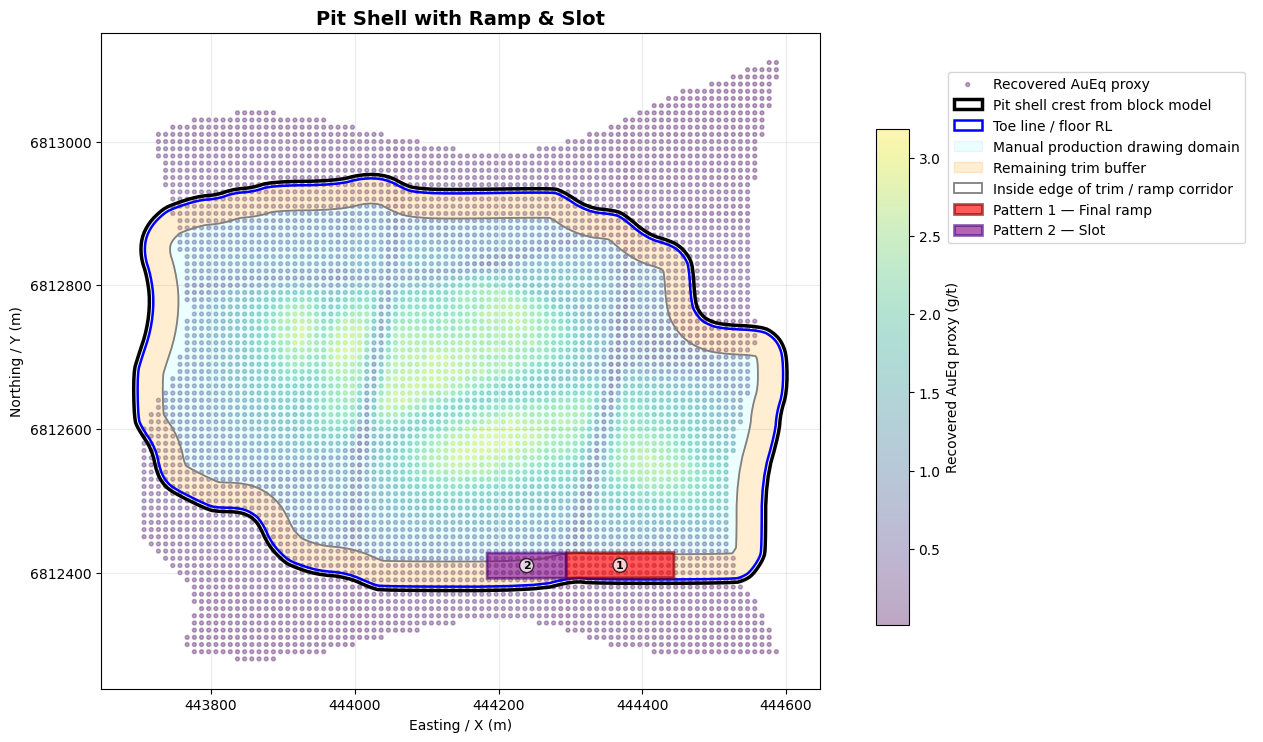

In [6]:
fig = plt.figure(figsize=(13, 8))

ax = fig.add_axes([0.07, 0.10, 0.58, 0.82])
cax = fig.add_axes([0.68, 0.18, 0.025, 0.62])
lax = fig.add_axes([0.73, 0.58, 0.24, 0.30])
lax.axis("off")

# Background grade/value proxy from the updated block model
scatter = ax.scatter(
    block_model_df[x_col],
    block_model_df[y_col],
    c=block_model_df["au_eq_gpt"],
    s=8,
    alpha=0.35,
    cmap="viridis",
    label="Recovered AuEq proxy",
    zorder=1,
)

plot_polygon(
    ax,
    pit_shell_polygon,
    facecolor="none",
    edgecolor="black",
    linewidth=2.5,
    label="Pit shell crest from block model",
    zorder=5,
)

plot_polygon(
    ax,
    toe_line_polygon,
    facecolor="none",
    edgecolor="blue",
    linewidth=1.8,
    label="Toe line / floor RL",
    zorder=5,
)

plot_polygon(
    ax,
    production_blast_domain,
    facecolor="cyan",
    edgecolor="steelblue",
    alpha=0.08,
    linewidth=1.0,
    label="Manual production drawing domain",
    zorder=2,
)

plot_polygon(
    ax,
    trim_blast_zone_remaining,
    facecolor="orange",
    edgecolor="darkorange",
    alpha=0.18,
    linewidth=1.0,
    label="Remaining trim buffer",
    zorder=2,
)

plot_polygon(
    ax,
    inner_trim_edge_polygon,
    facecolor="none",
    edgecolor="grey",
    linewidth=1.3,
    label="Inside edge of trim / ramp corridor",
    zorder=5,
)

plot_polygon(
    ax,
    final_ramp_polygon,
    facecolor="red",
    edgecolor="darkred",
    alpha=0.65,
    linewidth=2,
    label="Pattern 1 — Final ramp",
    zorder=8,
)

plot_polygon(
    ax,
    slot_pattern_polygon,
    facecolor="purple",
    edgecolor="indigo",
    alpha=0.60,
    linewidth=2,
    label="Pattern 2 — Slot",
    zorder=8,
)

for pid, poly in [
    (1, final_ramp_polygon),
    (2, slot_pattern_polygon),
]:
    add_blast_label(ax, pid, poly)

setup_plan_axis(
    ax,
    "Pit Shell with Ramp & Slot",
)

existing_legend = ax.get_legend()
if existing_legend is not None:
    existing_legend.remove()

cbar = fig.colorbar(scatter, cax=cax)
cbar.set_label("Recovered AuEq proxy (g/t)")

handles, labels = ax.get_legend_handles_labels()

lax.legend(
    handles,
    labels,
    loc="upper left",
    frameon=True,
)

plt.show()

## 7. Setup for manual production blasts

Initialise storage for the production blasts that I’m going to draw manually.

Keeping these separate so they can be reviewed, adjusted, and exported later.

In [7]:
manual_production_blasts = []
current_polygon_points = []

print("Manual blast storage initialised.")
print(f"Pattern 1 = ramp, Pattern 2 = slot, next manual blast = Pattern {manual_blast_counter_start}.")

Manual blast storage initialised.
Pattern 1 = ramp, Pattern 2 = slot, next manual blast = Pattern 3.


In [8]:
# ============================================================
# LOAD EXISTING MANUAL BLAST DATASET
# ============================================================

try:
    default_manual_load_path = _resolve_input_file(manual_context_geometry_file)
except Exception:
    default_manual_load_path = "exports/manual_blast_geometry.csv"

load_file_input = widgets.Text(
    value=default_manual_load_path,
    description="Geometry CSV:",
    layout=widgets.Layout(width="650px"),
)

load_mode_dropdown = widgets.Dropdown(
    options=[
        "Replace current editable blasts",
        "Append to current editable blasts",
    ],
    value="Replace current editable blasts",
    description="Load mode:",
    layout=widgets.Layout(width="330px"),
)

legacy_transform_dropdown = widgets.Dropdown(
    options=[
        ("Do not transform coordinates", "none"),
        ("Fit legacy bounds to current shell", "fit_bounds_to_current_shell"),
    ],
    value=default_legacy_geometry_transform,
    description="Legacy:",
    layout=widgets.Layout(width="330px"),
)

load_button = widgets.Button(
    description="Load Existing Blasts",
    button_style="info",
)

load_status = widgets.HTML(value="<b>Status:</b> No existing blast file loaded.")


def load_manual_blast_geometry(
    csv_path: str,
    transform_mode: str = "none",
):
    """Load, optionally transform, and clip manually drawn blast polygons."""
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Could not find file: {csv_path}")

    loaded_blasts = geometry_to_blasts_from_csv(csv_path)

    if transform_mode == "fit_bounds_to_current_shell":
        loaded_blasts = fit_blasts_bounds_to_domain(
            blasts=loaded_blasts,
            target_domain=design_boundary_polygon,
            margin_fraction=0.04,
            uniform_scale=True,
        )
    elif transform_mode != "none":
        raise ValueError("transform_mode must be 'none' or 'fit_bounds_to_current_shell'.")

    clipped_blasts = []

    for blast in loaded_blasts:
        clipped = clip_blast_to_domain(blast)
        if clipped is not None:
            clipped_blasts.append(clipped)

    return clipped_blasts


def renumber_blasts_from(blasts: list[dict], start_pattern_id: int) -> list[dict]:
    """Renumber loaded/editable blasts sequentially from start_pattern_id."""
    out = []

    for i, blast in enumerate(blasts):
        updated = blast.copy()
        updated["pattern_id"] = start_pattern_id + i
        out.append(updated)

    return out


def on_load_clicked(_):
    global manual_production_blasts

    try:
        loaded = load_manual_blast_geometry(
            load_file_input.value,
            transform_mode=legacy_transform_dropdown.value,
        )

        if not loaded:
            load_status.value = (
                "<b>Status:</b> No valid polygons loaded after clipping. "
                "If this is a legacy file from the old shell, use the legacy bounds-fit option."
            )
            return

        if load_mode_dropdown.value.startswith("Replace"):
            loaded = renumber_blasts_from(loaded, start_pattern_id=manual_blast_counter_start)
            manual_production_blasts.clear()
            manual_production_blasts.extend(loaded)
        else:
            start_id = max([manual_blast_counter_start - 1] + [b["pattern_id"] for b in manual_production_blasts]) + 1
            loaded = renumber_blasts_from(loaded, start_pattern_id=start_id)
            manual_production_blasts.extend(loaded)

        load_status.value = (
            f"<b>Status:</b> Loaded {len(loaded)} editable blast(s) "
            f"from <code>{load_file_input.value}</code>."
        )

        if "refresh_edit_pattern_options" in globals():
            refresh_edit_pattern_options()

        if "redraw_manual_blast_artists" in globals():
            redraw_manual_blast_artists()

    except Exception as e:
        load_status.value = f"<b>Status:</b> Load failed — {e}"


load_button.on_click(on_load_clicked)

display(widgets.VBox([
    widgets.HBox([load_file_input, load_button]),
    widgets.HBox([load_mode_dropdown, legacy_transform_dropdown]),
    load_status,
]))

## 8. Draw production blasts (manual)

Interactive canvas for laying out the remaining blasts.

Click points to sketch out a polygon, then save it as a blast. Repeat for each pattern.

This is intentionally manual for now - easier to control the geometry and avoid the odd shapes that crept in with the automated approach.

In [16]:
%matplotlib widget

In [17]:
plt.ioff()

fig, ax = plt.subplots(figsize=(12, 8))

fig.canvas.toolbar_visible = False
fig.canvas.header_visible = False
fig.canvas.footer_visible = True
fig.canvas.resizable = True

# ------------------------------------------------------------
# Base geometry
# ------------------------------------------------------------

ax.scatter(
    block_model_df[x_col],
    block_model_df[y_col],
    c=block_model_df["au_eq_gpt"],
    s=6,
    alpha=0.25,
    cmap="viridis",
    label="Recovered AuEq proxy",
    zorder=1,
)

plot_polygon(
    ax,
    pit_shell_polygon,
    facecolor="none",
    edgecolor="black",
    linewidth=2.5,
    label="Pit shell crest",
    zorder=5,
)

plot_polygon(
    ax,
    toe_line_polygon,
    facecolor="none",
    edgecolor="blue",
    linewidth=2,
    label="Toe line / floor RL",
    zorder=5,
)

plot_polygon(
    ax,
    trim_blast_zone_remaining,
    facecolor="orange",
    edgecolor="darkorange",
    alpha=0.16,
    linewidth=1.0,
    label="Remaining trim buffer",
    zorder=2,
)

plot_polygon(
    ax,
    production_blast_domain,
    facecolor="cyan",
    edgecolor="steelblue",
    alpha=0.06,
    linewidth=1.0,
    label="Manual production drawing domain",
    zorder=2,
)

plot_polygon(
    ax,
    inner_trim_edge_polygon,
    facecolor="none",
    edgecolor="grey",
    linewidth=1.5,
    label="Inside edge of trim / ramp corridor",
    zorder=5,
)

plot_polygon(
    ax,
    final_ramp_polygon,
    facecolor="red",
    edgecolor="darkred",
    alpha=0.65,
    linewidth=2,
    label="Pattern 1 — Final ramp",
    zorder=8,
)

plot_polygon(
    ax,
    slot_pattern_polygon,
    facecolor="purple",
    edgecolor="indigo",
    alpha=0.60,
    linewidth=2,
    label="Pattern 2 — Slot",
    zorder=8,
)

for pid, poly in [
    (1, final_ramp_polygon),
    (2, slot_pattern_polygon),
]:
    add_blast_label(ax, pid, poly)

ax.set_aspect("equal", adjustable="box")
ax.set_title("Interactive Manual Blast Drawing and Editing Canvas", fontsize=14, fontweight="bold")
ax.set_xlabel("Easting / X (m)")
ax.set_ylabel("Northing / Y (m)")
ax.grid(True, alpha=0.25)

ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
home_xlim = ax.get_xlim()
home_ylim = ax.get_ylim()

# Move legend outside the drawing area.
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=True,
)

plt.tight_layout()

# ------------------------------------------------------------
# Interactive drawing state
# ------------------------------------------------------------

current_line, = ax.plot([], [], marker="o", linestyle="-", linewidth=2, label="Current polygon")
saved_artists = []
saved_blast_artist_groups = []
saved_blast_labels = []

edit_vertices = []
selected_vertex_idx = None
edit_vertex_markers = []
selected_vertex_marker = None
edit_polygon_line = None

status = widgets.HTML(
    value=f"<b>Status:</b> Click points to begin drawing Pattern {max([manual_blast_counter_start - 1] + [b['pattern_id'] for b in manual_production_blasts]) + 1}."
)

save_button = widgets.Button(
    description="Save Blast",
    button_style="success",
    tooltip="Close and save the current polygon",
)

mode_dropdown = widgets.Dropdown(
    options=["Draw new blast", "Edit existing blast"],
    value="Draw new blast",
    description="Mode:",
    layout=widgets.Layout(width="260px"),
)

blast_type_dropdown = widgets.Dropdown(
    options=["Production", "Trim"],
    value="Production",
    description="Blast type:",
    layout=widgets.Layout(width="240px"),
)

edit_pattern_dropdown = widgets.Dropdown(
    options=[
        (f"Pattern {b['pattern_id']} — {b['pattern_type']}", b["pattern_id"])
        for b in manual_production_blasts
    ],
    description="Edit:",
    layout=widgets.Layout(width="360px"),
)

save_edits_button = widgets.Button(
    description="Save Edits",
    button_style="success",
    tooltip="Save edits to the selected polygon",
)

undo_button = widgets.Button(
    description="Undo Point",
    button_style="warning",
    tooltip="Remove the most recent point",
)

clear_button = widgets.Button(
    description="Clear Current",
    button_style="danger",
    tooltip="Clear the current unsaved polygon",
)

finish_button = widgets.Button(
    description="Finish",
    button_style="primary",
    tooltip="Finish drawing/editing production blasts",
)

undo_blast_button = widgets.Button(
    description="Undo Last Blast",
    button_style="warning",
    tooltip="Remove the most recently saved editable blast polygon",
)

zoom_in_button = widgets.Button(
    description="Zoom In",
    button_style="",
    tooltip="Zoom in around the current plot centre",
)

zoom_out_button = widgets.Button(
    description="Zoom Out",
    button_style="",
    tooltip="Zoom out around the current plot centre",
)

home_button = widgets.Button(
    description="Home View",
    button_style="",
    tooltip="Reset to the original plot extent",
)


def refresh_current_line():
    """Refresh the temporary polygon line on the canvas."""
    if len(current_polygon_points) == 0:
        current_line.set_data([], [])
    else:
        xs = [p[0] for p in current_polygon_points]
        ys = [p[1] for p in current_polygon_points]
        current_line.set_data(xs, ys)

    fig.canvas.draw_idle()


def next_pattern_id():
    """Return the next editable blast pattern ID."""
    return max([manual_blast_counter_start - 1] + [b["pattern_id"] for b in manual_production_blasts]) + 1


def on_click(event):
    """Handle canvas clicks for drawing or editing."""
    global selected_vertex_idx

    if event.inaxes != ax:
        return

    if event.xdata is None or event.ydata is None:
        return

    if event.button is not None and str(event.button).lower() not in ["1", "mousebutton.left"]:
        return

    # --------------------------------------------------------
    # Draw new blast mode
    # --------------------------------------------------------
    if mode_dropdown.value == "Draw new blast":
        current_polygon_points.append((event.xdata, event.ydata))

        status.value = (
            f"<b>Status:</b> Drawing Pattern {next_pattern_id()} — "
            f"{len(current_polygon_points)} point(s) selected. "
            f"Last point: ({event.xdata:.1f}, {event.ydata:.1f})"
        )

        refresh_current_line()
        return

    # --------------------------------------------------------
    # Edit existing blast mode
    # --------------------------------------------------------
    if mode_dropdown.value == "Edit existing blast":
        if not edit_vertices:
            load_selected_polygon_for_edit()
            return

        # If no vertex is selected, select nearest vertex
        if selected_vertex_idx is None:
            idx, dist = nearest_edit_vertex(event.xdata, event.ydata)

            if idx is None:
                return

            selected_vertex_idx = idx
            update_selected_vertex_marker()

            status.value = (
                f"<b>Status:</b> Selected vertex {idx + 1}. "
                "Click a new location to move it."
            )
            return

        # If a vertex is already selected, move it to the clicked location
        edit_vertices[selected_vertex_idx] = (event.xdata, event.ydata)

        status.value = (
            f"<b>Status:</b> Moved vertex {selected_vertex_idx + 1} "
            f"to ({event.xdata:.1f}, {event.ydata:.1f}). "
            "Click Save Edits to update the polygon."
        )

        selected_vertex_idx = None
        redraw_edit_polygon_from_vertices()


def on_save_clicked(_):
    """Close and save the current polygon as an editable blast."""
    if len(current_polygon_points) < 3:
        status.value = "<b>Status:</b> Select at least 3 points before saving a blast."
        return

    candidate_polygon = clean_polygon(Polygon(current_polygon_points))

    if candidate_polygon.is_empty or candidate_polygon.area <= 0:
        status.value = "<b>Status:</b> Invalid polygon. Clear current points and redraw."
        return

    blast_type = blast_type_dropdown.value
    drawing_domain = get_drawing_domain(blast_type)

    saved_polygon = safe_intersection(candidate_polygon, drawing_domain)

    # Prevent overlap with previous editable blasts
    already_assigned = Polygon()

    for blast in manual_production_blasts:
        already_assigned = safe_union([already_assigned, blast["polygon"]])

    saved_polygon = safe_difference(saved_polygon, already_assigned)

    if saved_polygon.is_empty or saved_polygon.area <= 0:
        status.value = (
            "<b>Status:</b> Saved polygon has no valid remaining area after clipping. "
            "Try drawing in an unassigned production or trim area."
        )
        return

    if saved_polygon.geom_type == "MultiPolygon":
        saved_polygon = max(saved_polygon.geoms, key=lambda g: g.area)

    pattern_id = next_pattern_id()

    manual_production_blasts.append({
        "pattern_id": pattern_id,
        "pattern_type": blast_type,
        "pattern_source": "manual_drawn",
        "polygon": saved_polygon,
        "area_m2": saved_polygon.area,
    })

    current_polygon_points.clear()
    refresh_current_line()
    redraw_manual_blast_artists()

    status.value = (
        f"<b>Status:</b> Pattern {pattern_id} saved. "
        f"Area = {saved_polygon.area:,.0f} m². "
        f"Click points to begin Pattern {next_pattern_id()}."
    )

    refresh_edit_pattern_options()


def on_undo_clicked(_):
    """Remove the most recent point."""
    if current_polygon_points:
        current_polygon_points.pop()

    status.value = (
        f"<b>Status:</b> Drawing Pattern {next_pattern_id()} — "
        f"{len(current_polygon_points)} point(s) selected."
    )

    refresh_current_line()


def on_clear_clicked(_):
    """Clear the current unsaved polygon."""
    current_polygon_points.clear()

    status.value = (
        f"<b>Status:</b> Current polygon cleared. "
        f"Click points to begin Pattern {next_pattern_id()}."
    )

    refresh_current_line()


def on_finish_clicked(_):
    """Disconnect the click handler and finish drawing/editing."""
    fig.canvas.mpl_disconnect(click_connection_id)

    current_polygon_points.clear()
    refresh_current_line()

    status.value = (
        f"<b>Status:</b> Finished. "
        f"{len(manual_production_blasts)} editable blast(s) saved."
    )


def on_undo_blast_clicked(_):
    """Remove the most recently saved editable blast polygon."""
    if not manual_production_blasts:
        status.value = "<b>Status:</b> No saved editable blasts to undo."
        return

    removed_blast = manual_production_blasts.pop()
    redraw_manual_blast_artists()

    status.value = (
        f"<b>Status:</b> Removed Pattern {removed_blast['pattern_id']}. "
        f"Next blast will be Pattern {next_pattern_id()}."
    )

    refresh_edit_pattern_options()


def on_mode_changed(change):
    """Respond to mode changes."""
    global selected_vertex_idx

    if change["name"] != "value":
        return

    selected_vertex_idx = None
    clear_edit_markers()

    if change["new"] == "Edit existing blast":
        refresh_edit_pattern_options()
        redraw_manual_blast_artists()
        load_selected_polygon_for_edit()

    else:
        show_manual_blasts_for_drawing()


def on_edit_pattern_changed(change):
    """Load another polygon when edit selection changes."""
    if change["name"] != "value":
        return

    if mode_dropdown.value == "Edit existing blast":
        load_selected_polygon_for_edit()


def on_save_edits_clicked(_):
    """Save edited vertices back into the selected editable blast polygon."""
    global edit_vertices, selected_vertex_idx

    if mode_dropdown.value != "Edit existing blast":
        status.value = "<b>Status:</b> Switch to Edit existing blast mode first."
        return

    if len(edit_vertices) < 3:
        status.value = "<b>Status:</b> Need at least 3 vertices to save polygon edits."
        return

    pattern_id = edit_pattern_dropdown.value
    blast = get_manual_blast_by_id(pattern_id)

    if blast is None:
        status.value = "<b>Status:</b> Selected blast not found."
        return

    edited_poly = clean_polygon(Polygon(edit_vertices))

    drawing_domain = get_drawing_domain(blast["pattern_type"])
    edited_poly = safe_intersection(edited_poly, drawing_domain)

    if edited_poly.geom_type == "MultiPolygon":
        edited_poly = max(edited_poly.geoms, key=lambda g: g.area)

    edited_poly = clean_polygon(edited_poly)

    if edited_poly.is_empty or edited_poly.area <= 0:
        status.value = "<b>Status:</b> Edited polygon is invalid after clipping."
        return

    blast["polygon"] = edited_poly
    blast["area_m2"] = edited_poly.area
    blast["pattern_source"] = "edited"

    selected_vertex_idx = None

    redraw_manual_blast_artists()
    load_selected_polygon_for_edit()

    status.value = (
        f"<b>Status:</b> Saved edits to Pattern {pattern_id}. "
        f"Updated area = {edited_poly.area:,.0f} m²."
    )


def zoom_axis(scale_factor):
    """Zoom the current axes around the current centre."""
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    x_mid = (x0 + x1) / 2
    y_mid = (y0 + y1) / 2

    x_half = (x1 - x0) * scale_factor / 2
    y_half = (y1 - y0) * scale_factor / 2

    ax.set_xlim(x_mid - x_half, x_mid + x_half)
    ax.set_ylim(y_mid - y_half, y_mid + y_half)

    fig.canvas.draw_idle()


def on_zoom_in_clicked(_):
    zoom_axis(0.7)


def on_zoom_out_clicked(_):
    zoom_axis(1.3)


def on_home_clicked(_):
    ax.set_xlim(home_xlim)
    ax.set_ylim(home_ylim)
    fig.canvas.draw_idle()


controls_top = widgets.HBox([
    mode_dropdown,
    blast_type_dropdown,
    edit_pattern_dropdown,
    save_edits_button,
])

controls_bottom = widgets.HBox([
    save_button,
    undo_button,
    undo_blast_button,
    clear_button,
    zoom_in_button,
    zoom_out_button,
    home_button,
    finish_button,
])

mode_dropdown.observe(on_mode_changed, names="value")
edit_pattern_dropdown.observe(on_edit_pattern_changed, names="value")
save_edits_button.on_click(on_save_edits_clicked)

click_connection_id = fig.canvas.mpl_connect("button_press_event", on_click)

save_button.on_click(on_save_clicked)
undo_button.on_click(on_undo_clicked)
undo_blast_button.on_click(on_undo_blast_clicked)
clear_button.on_click(on_clear_clicked)
zoom_in_button.on_click(on_zoom_in_clicked)
zoom_out_button.on_click(on_zoom_out_clicked)
home_button.on_click(on_home_clicked)
finish_button.on_click(on_finish_clicked)

plt.subplots_adjust(right=0.75)

# Draw current starter/editable blasts once the canvas state exists.
redraw_manual_blast_artists()

ui = widgets.VBox([
    controls_top,
    controls_bottom,
    status,
    fig.canvas,
])

display(ui)

## 9. Summary + export

Convert the drawn blasts into a simple table.

Mainly just checking IDs and areas here, but also exporting so I’ve got something to reuse without redrawing everything.

In [11]:
blast_polygons = get_all_blast_polygons()

blast_master_summary = summarise_blasts_against_block_model(
    blasts=blast_polygons,
    df=block_model_df,
    x_col=x_col,
    y_col=y_col,
    bench_height=bench_height_m,
)

# ------------------------------------------------------------
# Define export folder and filenames
# ------------------------------------------------------------

export_dir = "exports"
os.makedirs(export_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

summary_file = os.path.join(export_dir, f"blast_master_summary_{timestamp}.csv")
geometry_file = os.path.join(export_dir, f"blast_master_geometry_{timestamp}.csv")

# ------------------------------------------------------------
# Export summary
# ------------------------------------------------------------

blast_master_summary.to_csv(summary_file, index=False)

# ------------------------------------------------------------
# Build geometry dataframe (vertex-level export)
# ------------------------------------------------------------

geometry_rows = []

for blast in blast_polygons:
    poly = blast["polygon"]

    if poly.is_empty:
        continue

    if poly.geom_type == "MultiPolygon":
        poly = max(poly.geoms, key=lambda g: g.area)

    coords = list(poly.exterior.coords)

    for i, (x, y) in enumerate(coords):
        geometry_rows.append({
            "pattern_id": blast["pattern_id"],
            "pattern_type": blast["pattern_type"],
            "pattern_source": blast.get("pattern_source", "manual"),
            "point_id": i + 1,
            "x": x,
            "y": y,
            "floor_rl": floor_rl,
            "crest_rl": crest_rl,
        })

geometry_df = pd.DataFrame(geometry_rows)

geometry_df.to_csv(geometry_file, index=False)

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print(f"Blast master summary exported to: {summary_file}")
print(f"Blast master geometry exported to: {geometry_file}")

blast_master_summary


Blast master summary exported to: exports\blast_master_summary_20260518_050039.csv
Blast master geometry exported to: exports\blast_master_geometry_20260518_050039.csv


,pattern_id,pattern_type,pattern_source,area_m2,bench_height_m,volume_m3,mean_density_tpm3,tonnes_est,blocks_in_pattern,ore_fraction,mean_au_gpt,mean_cu_pct,mean_ag_gpt,mean_au_eq_gpt,mean_RMR,mean_UCS_MPa,mean_fault_dist_m,mean_pf_target_kgpm3,mean_target_p80_mm
0,1,Ramp,fixed_access,5250.0,15.0,78750.0,2.732667,215197.5,45,0.0,0.264778,0.019011,0.852667,0.260999,63.300000,125.755556,259.315556,1.068222,133.333333
1,2,Slot,fixed_slot,3850.0,15.0,57750.0,2.733636,157867.5,33,0.0,0.361030,0.027539,1.234242,0.355613,62.254545,123.906061,230.251515,1.059697,135.757576


## 10. Convert to 3D

Lift the 2D polygons into 3D.

Bottom is at the floor RL, top is offset back out to the crest using the toe offset. This keeps everything consistent with the bench geometry.

In [12]:
def outward_offset_polygon(poly: Polygon, offset_distance: float) -> Polygon:
    """
    Offset a polygon outward.

    Used here to reconstruct the crest-level footprint from the toe/floor-level
    footprint using the bench toe offset.
    """
    if poly.is_empty:
        return poly

    out = clean_geometry(poly.buffer(offset_distance, join_style=2))

    if out.geom_type == "MultiPolygon":
        out = max(out.geoms, key=lambda g: g.area)

    return clean_polygon(out)


def polygon_to_3d_vertices(
    poly: Polygon,
    pattern_id: int,
    pattern_type: str,
    pattern_source: str,
    bottom_rl: float,
    top_rl: float,
    toe_offset: float,
    current_polygon_is_toe_based: bool = True,
) -> pd.DataFrame:
    """
    Convert a 2D blast polygon into top and bottom 3D vertices.

    If current_polygon_is_toe_based=True:
        - input polygon is treated as the bottom/floor/toe footprint
        - top polygon is offset outward by toe_offset

    If current_polygon_is_toe_based=False:
        - input polygon is treated as the top/crest footprint
        - bottom polygon is offset inward by toe_offset
    """
    if poly.is_empty:
        return pd.DataFrame()

    if poly.geom_type == "MultiPolygon":
        poly = max(poly.geoms, key=lambda g: g.area)

    poly = clean_polygon(poly)

    if current_polygon_is_toe_based:
        bottom_poly = poly
        top_poly = outward_offset_polygon(poly, toe_offset)
    else:
        top_poly = poly
        bottom_poly = clean_polygon(poly.buffer(-toe_offset, join_style=2))

    if bottom_poly.is_empty or top_poly.is_empty:
        return pd.DataFrame()

    bottom_coords = list(bottom_poly.exterior.coords)
    top_coords = list(top_poly.exterior.coords)

    rows = []

    for i, (x, y) in enumerate(bottom_coords, start=1):
        rows.append({
            "pattern_id": pattern_id,
            "pattern_type": pattern_type,
            "pattern_source": pattern_source,
            "surface": "bottom_toe_floor",
            "vertex_id": i,
            "x": x,
            "y": y,
            "z_rl": bottom_rl,
        })

    for i, (x, y) in enumerate(top_coords, start=1):
        rows.append({
            "pattern_id": pattern_id,
            "pattern_type": pattern_type,
            "pattern_source": pattern_source,
            "surface": "top_crest",
            "vertex_id": i,
            "x": x,
            "y": y,
            "z_rl": top_rl,
        })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Build list of all blast polygons
# ------------------------------------------------------------

blast_polygons = get_all_blast_polygons()

# ------------------------------------------------------------
# Convert to 3D vertex table
# ------------------------------------------------------------

blast_3d_vertices_df = pd.concat(
    [
        polygon_to_3d_vertices(
            poly=blast["polygon"],
            pattern_id=blast["pattern_id"],
            pattern_type=blast["pattern_type"],
            pattern_source=blast.get("pattern_source", "manual"),
            bottom_rl=floor_rl,
            top_rl=crest_rl,
            toe_offset=toe_offset_m,
            current_polygon_is_toe_based=True,
        )
        for blast in blast_polygons
    ],
    ignore_index=True,
)

blast_3d_vertices_df

,pattern_id,pattern_type,pattern_source,surface,vertex_id,x,y,z_rl
0,1,Ramp,fixed_access,bottom_toe_floor,1,444444.170932,6.812393e+06,185.0
1,1,Ramp,fixed_access,bottom_toe_floor,2,444294.171687,6.812393e+06,185.0
2,1,Ramp,fixed_access,bottom_toe_floor,3,444294.060574,6.812428e+06,185.0
3,1,Ramp,fixed_access,bottom_toe_floor,4,444444.059818,6.812428e+06,185.0
4,1,Ramp,fixed_access,bottom_toe_floor,5,444444.170932,6.812393e+06,185.0
5,1,Ramp,fixed_access,top_crest,1,444449.647790,6.812388e+06,200.0
6,1,Ramp,fixed_access,top_crest,2,444288.729494,6.812387e+06,200.0
7,1,Ramp,fixed_access,top_crest,3,444288.583715,6.812433e+06,200.0
8,1,Ramp,fixed_access,top_crest,4,444449.502011,6.812434e+06,200.0
9,1,Ramp,fixed_access,top_crest,5,444449.647790,6.812388e+06,200.0


In [13]:
blast_3d_vertices_file = os.path.join(
    export_dir,
    f"blast_3d_vertices_{timestamp}.csv"
)

blast_3d_vertices_df.to_csv(blast_3d_vertices_file, index=False)

print(f"3D blast vertices exported to: {blast_3d_vertices_file}")

3D blast vertices exported to: exports\blast_3d_vertices_20260518_050039.csv


## 11. 3D view (wireframe)

Quick 3D check of individual patterns.

Mostly for visual QA - making sure the shapes look right in space before doing anything more detailed with them.

In [14]:
pattern_options = [
    (
        f"Pattern {blast['pattern_id']} — {blast['pattern_type']}",
        blast["pattern_id"],
    )
    for blast in blast_polygons
]

pattern_dropdown = widgets.Dropdown(
    options=pattern_options,
    description="Pattern:",
    layout=widgets.Layout(width="420px"),
)

viewer_output = widgets.Output()


def get_pattern_3d_vertices(pattern_id: int) -> pd.DataFrame:
    """Return 3D vertex data for a selected pattern."""
    return blast_3d_vertices_df[
        blast_3d_vertices_df["pattern_id"] == pattern_id
    ].copy()


def add_closed_wireframe_trace(fig, df, surface_name, trace_name):
    """Add a closed 3D wireframe trace for one surface."""
    surface_df = df[df["surface"] == surface_name].sort_values("vertex_id")

    if surface_df.empty:
        return

    fig.add_trace(
        go.Scatter3d(
            x=surface_df["x"],
            y=surface_df["y"],
            z=surface_df["z_rl"],
            mode="lines+markers",
            name=trace_name,
            line=dict(width=4),
            marker=dict(size=4),
        )
    )


def build_pattern_wireframe(pattern_id: int):
    """Build a 3D wireframe plot for the selected blast pattern."""
    df = get_pattern_3d_vertices(pattern_id)

    if df.empty:
        print(f"No 3D vertices found for Pattern {pattern_id}.")
        return

    pattern_type = df["pattern_type"].iloc[0]

    bottom_df = df[df["surface"] == "bottom_toe_floor"].sort_values("vertex_id")
    top_df = df[df["surface"] == "top_crest"].sort_values("vertex_id")

    fig = go.Figure()

    # Bottom and top closed outlines.
    add_closed_wireframe_trace(
        fig,
        df,
        surface_name="bottom_toe_floor",
        trace_name="Bottom / floor RL",
    )

    add_closed_wireframe_trace(
        fig,
        df,
        surface_name="top_crest",
        trace_name="Top / crest RL",
    )

    # Vertical connecting lines. Because top/bottom offsets can change vertex
    # counts, connect only the common ordered subset for a simple wireframe
    n_connect = min(len(bottom_df), len(top_df))

    for i in range(n_connect):
        b = bottom_df.iloc[i]
        t = top_df.iloc[i]

        fig.add_trace(
            go.Scatter3d(
                x=[b["x"], t["x"]],
                y=[b["y"], t["y"]],
                z=[b["z_rl"], t["z_rl"]],
                mode="lines",
                name="Wall connection" if i == 0 else None,
                showlegend=True if i == 0 else False,
                line=dict(width=3),
            )
        )

    fig.update_layout(
        title=f"3D Wireframe — Pattern {pattern_id}: {pattern_type}",
        height=750,
        scene=dict(
            xaxis=dict(
                title="Easting / X (m)",
                tickformat=".0f",
                separatethousands=False,
            ),
            yaxis=dict(
                title="Northing / Y (m)",
                tickformat=".0f",
                separatethousands=False,
            ),
            zaxis=dict(
                title="RL (m)",
                tickformat=".0f",
            ),
            aspectmode="data",
        ),
        margin=dict(l=0, r=0, t=50, b=0),
        legend=dict(
            x=0.02,
            y=0.98,
            bgcolor="rgba(255,255,255,0.75)",
        ),
    )

    fig.show()


def on_pattern_changed(change):
    """Update the 3D viewer when the selected pattern changes."""
    if change["name"] != "value":
        return

    with viewer_output:
        clear_output(wait=True)
        build_pattern_wireframe(change["new"])


pattern_dropdown.observe(on_pattern_changed, names="value")

display(pattern_dropdown, viewer_output)

with viewer_output:
    build_pattern_wireframe(pattern_dropdown.value)

Dropdown(description='Pattern:', layout=Layout(width='420px'), options=(('Pattern 1 — Ramp', 1), ('Pattern 2 —…

Output()